# Forecasting the S&P 500 Information Technology Sector (S5INFT) Using a Kalman Filter

Author: Rudransh Khera  

## Introduction

This project develops a Kalman filter forecasting strategy for the S&P 500 Information Technology Sector Index (S5INFT). We investigate whether combining slow-moving institutional earnings expectations with real-time retail sentiment, measured via Google Trends, can produce superior risk-adjusted returns when filtered through a time-varying coefficient model.

The technology sector is simultaneously driven by fundamental cash-flow growth and fast-moving narrative cycles. To capture both forces, we construct three predictor variables: (i) the 4-week momentum of 12-month Forward Earnings Per Share (EPS), reflecting institutional consensus shifts; (ii) the rolling Z-score of Google Trends search volume for "tech layoffs," proxying acute sector fear; and (iii) the rolling Z-score of Google Trends search volume for "artificial intelligence," proxying hype-driven retail optimism.

Our modeling approach evolved during the course of this project. We initially explored a simpler dual-threshold strategy, where static cutoffs on EPS momentum and fear sentiment would trigger Long or Cash positions. However, we found that fixed thresholds decayed quickly across changing market regimes, particularly around the 2022 tech selloff and the subsequent AI-driven rally. This motivated our pivot to a Kalman filter state-space model with time-varying regression coefficients, which allows the model to continuously update its estimates of how each factor relates to future S5INFT returns as new data arrives, naturally adapting to structural regime changes such as the COVID-19 shock, the 2022 rate-hike cycle, and the post-2023 Generative AI boom. A Walk-Forward Optimization engine with an expanding window recalibrates two hyperparameters (the state-noise variance $q$ and the signal threshold $\tau$) at the end of each calendar year, ensuring no look-ahead bias contaminates the out-of-sample backtest.

The strategy achieved a Sharpe Ratio of 1.025 compared to 0.949 for a passive buy-and-hold of S5INFT over the 2019 to 2026 testing period, with a lower maximum drawdown (-31.66% vs. -33.34%) and a positive annualized alpha of 10.67% against the S&P 500 benchmark. A Weighted Directional Test confirmed that the strategy's directional forecasts successfully captured significant price movements at the 1% level (test statistic 2.321, p = 0.010).

### Data Procurement

To construct this strategy, we procured multiple heterogeneous data series from three distinct source types:

**Bloomberg Terminal (Fundamental and Price Data):** We extracted weekly historical data for the S5INFT Last Price, the S5INFT 12-Month Forward Best EPS estimates, and the S&P 500 (SPX) Last Price. All Bloomberg series span from January 2000 through March 2026 (1,366 weekly observations each).

**FRED (Risk-Free Rate):** We sourced the Market Yield on U.S. Treasury Securities at 1-Year Constant Maturity (series DGS1) from the Federal Reserve Economic Data (FRED) database at weekly frequency (ending Friday, end-of-period), spanning January 2000 through March 2026 (1,367 observations). This matches the risk-free rate specified in the project guidelines.

**Google Trends (Alternative Sentiment Data):** We extracted monthly search volume data for two terms: "tech layoffs" (a proxy for sector-specific labor-market panic and retail fear) and "artificial intelligence" (a proxy for retail hype and narrative-driven optimism around transformative technology). Both series cover January 2010 through February 2026 (194 monthly observations each). The monthly observations are forward-filled to align with the weekly Bloomberg dates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Bloomberg Weekly Data
df_price = pd.read_excel('S5INFT- Last Price (Weekly).xlsx')
df_eps = pd.read_excel('S5INFT- BestEPS (Weekly).xlsx')
df_spx = pd.read_excel('SPX- Last Price (Weekly).xlsx')

# FRED Risk-Free Rate (1-Year Treasury Constant Maturity, Weekly)
df_rf = pd.read_excel('DGS1.xlsx')

# Google Trends Monthly Data
df_layoffs = pd.read_excel('Tech Layoffs.xlsx')
df_ai = pd.read_excel('Artificial Intelligence.xlsx')

# Process dates and set index for Bloomberg data
for d in [df_price, df_eps, df_spx]:
    d['Date'] = pd.to_datetime(d['Date'])
    d.set_index('Date', inplace=True)
    d.sort_index(inplace=True)

# Process FRED risk-free rate
df_rf['observation_date'] = pd.to_datetime(df_rf['observation_date'])
df_rf.set_index('observation_date', inplace=True)
df_rf.index.name = 'Date'
df_rf.sort_index(inplace=True)

# Process dates and set index for Google Trends data
for d in [df_layoffs, df_ai]:
    d.rename(columns={'Time': 'Date'}, inplace=True)
    d['Date'] = pd.to_datetime(d['Date'])
    d.set_index('Date', inplace=True)
    d.sort_index(inplace=True)

# Rename columns
df_price.rename(columns={'Last Price': 'S5INFT_Price'}, inplace=True)
df_eps.rename(columns={'BEst EPS': 'Forward_EPS'}, inplace=True)
df_spx.rename(columns={'Last Price': 'SPX_Price'}, inplace=True)
df_rf.rename(columns={'DGS1': 'RF_Yield'}, inplace=True)
df_layoffs.rename(columns={'tech layoffs': 'Fear_Index'}, inplace=True)
df_ai.rename(columns={'artificial intelligence': 'AI_Index'}, inplace=True)

# Join Bloomberg data on weekly dates
df = df_price.join([df_eps, df_spx, df_rf], how='outer')
df.sort_index(inplace=True)

# Upsample Google Trends (monthly) to daily via forward-fill, then join to weekly Bloomberg dates
daily_idx = pd.date_range(
    start=min(df_layoffs.index.min(), df_ai.index.min()),
    end=df.index.max(), freq='D'
)
df_layoffs_daily = df_layoffs.reindex(daily_idx).ffill()
df_ai_daily = df_ai.reindex(daily_idx).ffill()
df = df.join(df_layoffs_daily[['Fear_Index']], how='left')
df = df.join(df_ai_daily[['AI_Index']], how='left')

# Forward-fill remaining gaps and drop incomplete rows
df.ffill(inplace=True)
df.dropna(inplace=True)

print(f"Combined dataset: {df.shape[0]} weekly observations")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Columns: {list(df.columns)}")

Combined dataset: 847 weekly observations
Date range: 2010-01-01 to 2026-03-13
Columns: ['S5INFT_Price', 'Forward_EPS', 'SPX_Price', 'RF_Yield', 'Fear_Index', 'AI_Index']


In [2]:
# EPS Momentum: 4-week percentage change in Forward EPS
df['EPS_Momentum'] = df['Forward_EPS'].pct_change(periods=4)

# Fear Z-Score: Rolling 52-week Z-score of "tech layoffs" search volume
df['Fear_Z'] = (
    (df['Fear_Index'] - df['Fear_Index'].rolling(window=52).mean())
    / df['Fear_Index'].rolling(window=52).std()
)

# AI Hype Z-Score: Rolling 52-week Z-score of "artificial intelligence" search volume
df['AI_Z'] = (
    (df['AI_Index'] - df['AI_Index'].rolling(window=52).mean())
    / df['AI_Index'].rolling(window=52).std()
)

# Weekly returns
df['Asset_Ret'] = df['S5INFT_Price'].pct_change(periods=1)
df['SPX_Ret'] = df['SPX_Price'].pct_change(periods=1)

# Risk-free rate: convert annualized yield to weekly return
df['RF_Weekly'] = (1 + df['RF_Yield'] / 100) ** (1 / 52) - 1

# Forward-aligned returns: these represent the return earned NEXT week,
# matching the period during which the strategy is actually exposed
df['Forward_Asset_Ret'] = df['Asset_Ret'].shift(-1)
df['Forward_SPX_Ret'] = df['SPX_Ret'].shift(-1)
df['Forward_RF_Weekly'] = df['RF_Weekly'].shift(-1)

# Drop rows with NaNs from rolling computations
df.dropna(inplace=True)

print(f"Data shape after feature engineering: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nFeature summary statistics:")
display(df[['EPS_Momentum', 'Fear_Z', 'AI_Z', 'Forward_Asset_Ret']].describe().round(4))

Data shape after feature engineering: (768, 15)
Date range: 2011-07-01 to 2026-03-06

Feature summary statistics:


,EPS_Momentum,Fear_Z,AI_Z,Forward_Asset_Ret
count,768.0000,768.0000,768.0000,768.0000
mean,0.0097,0.2769,0.6214,0.0038
std,0.0568,1.3322,1.2622,0.0286
min,-0.0439,-3.0363,-2.3640,-0.1525
25%,-0.0080,-0.7108,-0.3502,-0.0113
50%,-0.0022,0.3230,0.6220,0.0042
75%,0.0041,0.8564,1.4924,0.0204
max,0.3542,7.0724,6.2921,0.1059


## Strategy and Conceptual Framework

### Economic Rationale

The technology sector is highly idiosyncratic. Unlike traditional utility or consumer-staple sectors, technology equities are driven simultaneously by massive, tangible cash flows and highly sensitive, narrative-driven hype cycles. Our conceptual framework merges these two realities through three complementary channels:

**Channel 1: Fundamental Momentum (Forward EPS).** Forward EPS estimates represent the aggregated, slow-moving institutional expectation of future cash flows. When these estimates are systematically revised upward, it signals a fundamentally sound expansion phase for the sector. Because analysts revise estimates gradually, EPS momentum tends to be persistent and captures the direction of medium-term earnings growth. We operationalize this as the 4-week percentage rate of change in the 12-month Forward Best EPS for S5INFT.

**Channel 2: Fear Sentiment ("tech layoffs").** Institutional estimates are notoriously slow to adapt to sudden macroeconomic shocks. Conversely, Google search traffic for "tech layoffs" acts as a high-frequency, real-time barometer of acute sector distress. A statistically significant spike in search volume, relative to its own recent history, indicates a panic environment where the sector's price multiple will likely contract aggressively, regardless of the underlying EPS trajectory at that exact moment. We normalize this as a rolling 52-week Z-score.

**Channel 3: Hype Sentiment ("artificial intelligence").** The explosive rise in public interest around artificial intelligence, particularly after the launch of ChatGPT in late 2022, created a powerful narrative-driven tailwind for tech valuations. However, from a contrarian standpoint, extreme spikes in AI search interest may signal overheated retail optimism, an environment where valuations have already priced in unrealistic growth expectations and are vulnerable to mean reversion. Critically, we do not impose a fixed assumption on whether AI hype is bullish or bearish. Instead, the Kalman filter dynamically learns the sign and magnitude of this relationship as it evolves over time.

### Kalman Filter State-Space Model

We model the one-week-ahead S5INFT return as a linear function of three time-varying factors. The key innovation is that the regression coefficients themselves evolve as a random walk, allowing the model to adapt to structural regime changes without manual intervention.

**Observation Equation:**

$$r_{t+1} = \mathbf{x}_t^\top \boldsymbol{\beta}_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, R)$$

**State Transition Equation:**

$$\boldsymbol{\beta}_t = \boldsymbol{\beta}_{t-1} + \boldsymbol{\eta}_t, \quad \boldsymbol{\eta}_t \sim \mathcal{N}(\mathbf{0}, Q)$$

Where:
- $r_{t+1}$ is the one-week-ahead return of S5INFT.
- $\mathbf{x}_t = [\text{EPS\_Mom}_t,\ \text{Fear\_Z}_t,\ \text{AI\_Z}_t]^\top$ is the $(3 \times 1)$ vector of observable predictors at time $t$.
- $\boldsymbol{\beta}_t = [\beta_{1,t},\ \beta_{2,t},\ \beta_{3,t}]^\top$ is the $(3 \times 1)$ vector of unobservable, time-varying coefficients.
- $R$ is the observation noise variance, estimated as the sample variance of returns in the training window.
- $Q = q \cdot I_3$ is the state noise covariance, where $q$ is a scalar hyperparameter controlling the rate of coefficient adaptation.

**Trading Signal:**

The one-step-ahead forecast $\hat{r}_{t+1} = \mathbf{x}_t^\top \hat{\boldsymbol{\beta}}_{t|t}$ is compared against a signal threshold $\tau$:

$$S_t = \begin{cases} 1 \ (\text{Long S5INFT}), & \text{if } \hat{r}_{t+1} > \tau \\ 0 \ (\text{Cash at Risk-Free Rate}), & \text{otherwise} \end{cases}$$

When the signal is 1, the strategy earns the S5INFT return for that week. When the signal is 0, the strategy earns the 1-Year Treasury weekly yield. The two hyperparameters $(q, \tau)$ are jointly optimized via walk-forward grid search to maximize cumulative return on the expanding training window.

In [3]:
def run_kalman_filter(X, y, q, R, n_features=3):
    """
    Time-varying coefficient Kalman filter for return forecasting.

    State-space model:
        Observation:  y_t = x_t^T * beta_t + eps_t,   eps_t ~ N(0, R)
        Transition:   beta_t = beta_{t-1} + eta_t,     eta_t ~ N(0, Q)

    Parameters
    ----------
    X : ndarray (T, n_features): predictor matrix
    y : ndarray (T,): forward returns (prediction target)
    q : float: state noise variance scaling (Q = q * I)
    R : float: observation noise variance
    n_features : int: number of predictors

    Returns
    -------
    predicted_returns : ndarray (T,): one-step-ahead return forecasts
    filtered_betas    : ndarray (T, n_features): filtered state estimates
    """
    T = len(y)
    Q = q * np.eye(n_features)

    # Initialize state: zero coefficients, unit covariance
    beta = np.zeros(n_features)
    P = np.eye(n_features) * 1.0

    predicted_returns = np.full(T, np.nan)
    filtered_betas = np.full((T, n_features), np.nan)

    for t in range(T):
        x_t = X[t]

        # Predict
        beta_pred = beta.copy()
        P_pred = P + Q

        # One-step-ahead forecast (made BEFORE observing y_t)
        predicted_returns[t] = x_t @ beta_pred

        # Update (after observing y_t)
        F_t = x_t @ P_pred @ x_t + R       # Innovation variance
        K_t = (P_pred @ x_t) / F_t          # Kalman gain
        v_t = y[t] - x_t @ beta_pred        # Innovation

        beta = beta_pred + K_t * v_t
        P = P_pred - np.outer(K_t, x_t @ P_pred)

        filtered_betas[t] = beta.copy()

    return predicted_returns, filtered_betas


def evaluate_strategy(predicted_returns, y, tau, rf=None):
    """Generate trading signals and compute cumulative return.
    When signal=1, earn asset return. When signal=0, earn risk-free rate."""
    signals = (predicted_returns > tau).astype(int)
    if rf is None:
        rf = np.zeros(len(y))
    strategy_returns = signals * y + (1 - signals) * rf
    cum_ret = (1 + strategy_returns).prod() - 1
    return signals, strategy_returns, cum_ret

print("Kalman filter functions defined.")

Kalman filter functions defined.


## Methodology

### Data Preprocessing and Transformations

The raw data required several mathematical transformations to serve as inputs to the Kalman filter. Raw Forward EPS was transformed into 4-week momentum so that the predictor captures the direction and rate of analyst revision activity rather than the absolute dollar level, which trends upward over time and would otherwise force the corresponding Kalman coefficient to drift simply to compensate for scale growth. Similarly, Google Trends search volumes were converted to rolling Z-scores to measure abnormal deviations relative to recent history rather than raw index values, ensuring the model responds to relative spikes in sentiment rather than secular trends in search behavior. These transformations are detailed below:

1. **EPS Momentum:** The raw Forward EPS level was converted into a 4-week rolling percentage rate of change: $\text{EPS\_Mom}_t = (EPS_t - EPS_{t-4}) / EPS_{t-4}$. This transforms an absolute dollar figure into a standardized momentum oscillator that measures the direction and magnitude of analyst revision activity.

2. **Fear Z-Score:** The raw Google Trends "tech layoffs" volume (bounded 0 to 100) was transformed into a rolling 52-week Z-score: $\text{Fear\_Z}_t = (F_t - \bar{F}_{52}) / \sigma_{F,52}$. This normalization identifies statistically significant spikes in fear relative to recent baseline levels, rather than relying on arbitrary absolute thresholds.

3. **AI Hype Z-Score:** The raw Google Trends "artificial intelligence" volume was identically transformed into a rolling 52-week Z-score, capturing abnormal surges in AI-related public attention relative to recent history.

4. **Risk-Free Rate:** The annualized 1-Year Treasury Constant Maturity yield was converted to a weekly return via (1+y/100)1/52−1(1 + y/100)^{1/52} - 1
(1+y/100)1/52−1.

5. **Forward Alignment:** All prediction targets and benchmark returns were shifted by one period to create properly forward-aligned series. The strategy's return in week $t$ is determined by the signal generated using information available at time $t$, applied to the return realized from $t$ to $t+1$. The SPX benchmark and risk-free rate used in performance evaluation are identically forward-aligned to ensure an apples-to-apples comparison.

After applying these transformations and dropping rows with insufficient history for the 52-week rolling windows, the final dataset contains 768 weekly observations spanning July 2011 through March 2026.

### Kalman Filter Recursion

At each time step $t$, the filter executes four operations:

1. **Predict:** $\hat{\boldsymbol{\beta}}_{t|t-1} = \hat{\boldsymbol{\beta}}_{t-1|t-1}$, $\quad P_{t|t-1} = P_{t-1|t-1} + Q$
2. **Forecast:** $\hat{r}_{t+1} = \mathbf{x}_t^\top \hat{\boldsymbol{\beta}}_{t|t-1}$ (one-step-ahead, made before observing $r_{t+1}$)
3. **Innovation:** $v_t = r_{t+1} - \mathbf{x}_t^\top \hat{\boldsymbol{\beta}}_{t|t-1}$, $\quad F_t = \mathbf{x}_t^\top P_{t|t-1} \mathbf{x}_t + R$
4. **Update:** $K_t = P_{t|t-1} \mathbf{x}_t / F_t$, $\quad \hat{\boldsymbol{\beta}}_{t|t} = \hat{\boldsymbol{\beta}}_{t|t-1} + K_t v_t$, $\quad P_{t|t} = P_{t|t-1} - K_t \mathbf{x}_t^\top P_{t|t-1}$

The state vector $\boldsymbol{\beta}$ is initialized at zero with identity covariance, reflecting an uninformative prior. The filter then learns the appropriate coefficients entirely from the data.

### Walk-Forward Optimization

We use a strict expanding-window Walk-Forward Optimization protocol to prevent look-ahead bias:

- **Initial Training Window:** July 2011 through December 2018 (392 weekly observations).
- **Test Period:** January 2019 through March 2026 (376 weekly observations, exceeding the 7-year minimum).
- **Recalibration Frequency:** At the end of each calendar year, the training window expands to include all data through that year. The hyperparameters $(q, \tau)$ are re-optimized via grid search over the expanded training set, maximizing cumulative strategy return.
- **Grid:** $q \in \{10^{-7}, 10^{-6.5}, \ldots, 10^{-3}\}$ (12 values, log-spaced) and $\tau \in \{-0.005, \ldots, 0.010\}$ (12 values, linearly spaced).
- The observation noise $R$ is re-estimated as the sample variance of forward returns in the current training window at each recalibration.

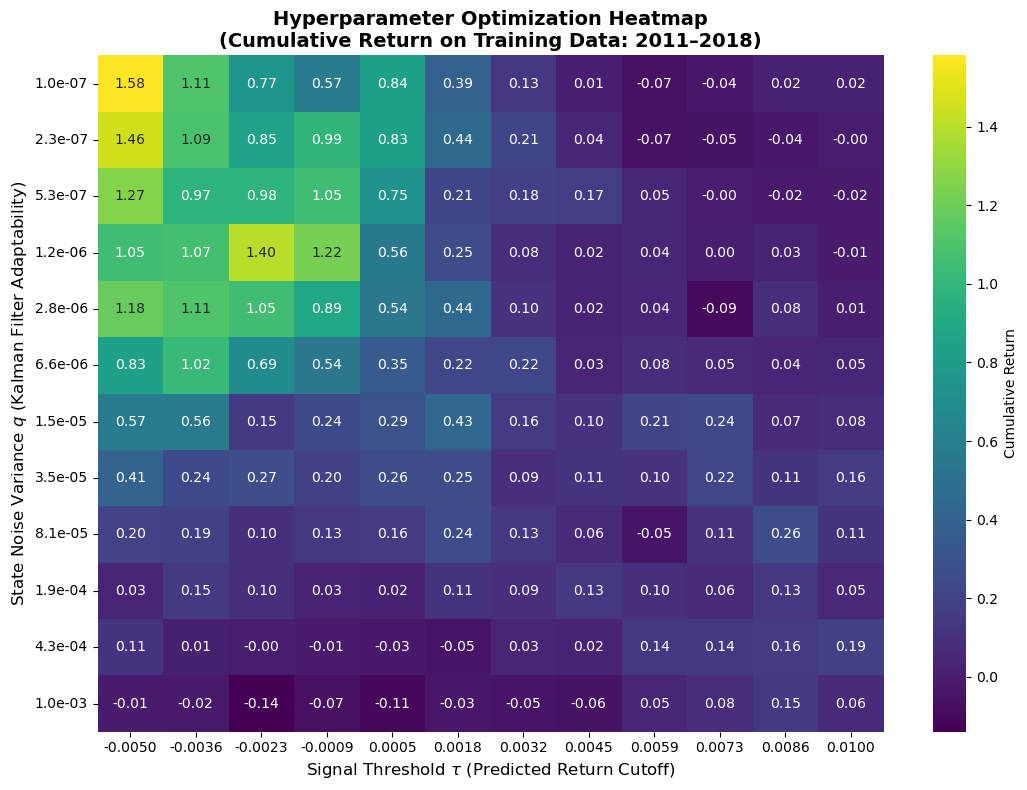


Best training parameters: q = 1.00e-07, τ = -0.005000
Best training cumulative return: 1.5820


In [4]:
train_df = df.loc['2011-01-01':'2018-12-31'].copy()
X_train = train_df[['EPS_Momentum', 'Fear_Z', 'AI_Z']].values
y_train = train_df['Forward_Asset_Ret'].values
rf_train = train_df['Forward_RF_Weekly'].values
R_train = np.var(y_train)

# Hyperparameter grids
q_values = np.logspace(-7, -3, 12)
tau_values = np.linspace(-0.005, 0.010, 12)

heatmap_results = np.zeros((len(q_values), len(tau_values)))

for i, q_val in enumerate(q_values):
    pred, _ = run_kalman_filter(X_train, y_train, q_val, R_train)
    for j, tau_val in enumerate(tau_values):
        _, _, cum_ret = evaluate_strategy(pred, y_train, tau_val, rf=rf_train)
        heatmap_results[i, j] = cum_ret

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    heatmap_results,
    xticklabels=[f"{t:.4f}" for t in tau_values],
    yticklabels=[f"{q:.1e}" for q in q_values],
    cmap='viridis', annot=True, fmt='.2f', ax=ax,
    cbar_kws={'label': 'Cumulative Return'}
)
ax.set_title('Hyperparameter Optimization Heatmap\n(Cumulative Return on Training Data: 2011–2018)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(r'Signal Threshold $\tau$ (Predicted Return Cutoff)', fontsize=12)
ax.set_ylabel(r'State Noise Variance $q$ (Kalman Filter Adaptability)', fontsize=12)
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(heatmap_results.argmax(), heatmap_results.shape)
print(f"\nBest training parameters: q = {q_values[best_idx[0]]:.2e}, τ = {tau_values[best_idx[1]]:.6f}")
print(f"Best training cumulative return: {heatmap_results[best_idx[0], best_idx[1]]:.4f}")

## Results

### Hyperparameter Heatmap (Training Data: 2011 to 2018)

The heatmap above displays the cumulative strategy return for each combination of state-noise variance $q$ and signal threshold $\tau$ on the initial training set. Several patterns emerge. First, the highest-return region (bright yellow, cumulative returns above 1.0) is concentrated in the upper-left quadrant: low $q$ values ($10^{-7}$ to $10^{-6}$) combined with low $\tau$ values ($-0.005$ to $-0.002$). This indicates that during the 2011 to 2018 training period, the optimal strategy used slowly-adapting coefficients (low state noise) and a permissive entry threshold. Second, performance degrades monotonically as $\tau$ increases, confirming that in the sustained tech bull market of this era, being invested was almost always preferable to sitting in cash. Third, very high $q$ values ($>10^{-4}$) produce near-zero or negative returns regardless of $\tau$, indicating that overly volatile coefficient estimates generate noise-driven whipsaw signals. The best training configuration was $q = 10^{-7}$, $\tau = -0.005$, producing a cumulative return of 1.58 (158% over the training period).

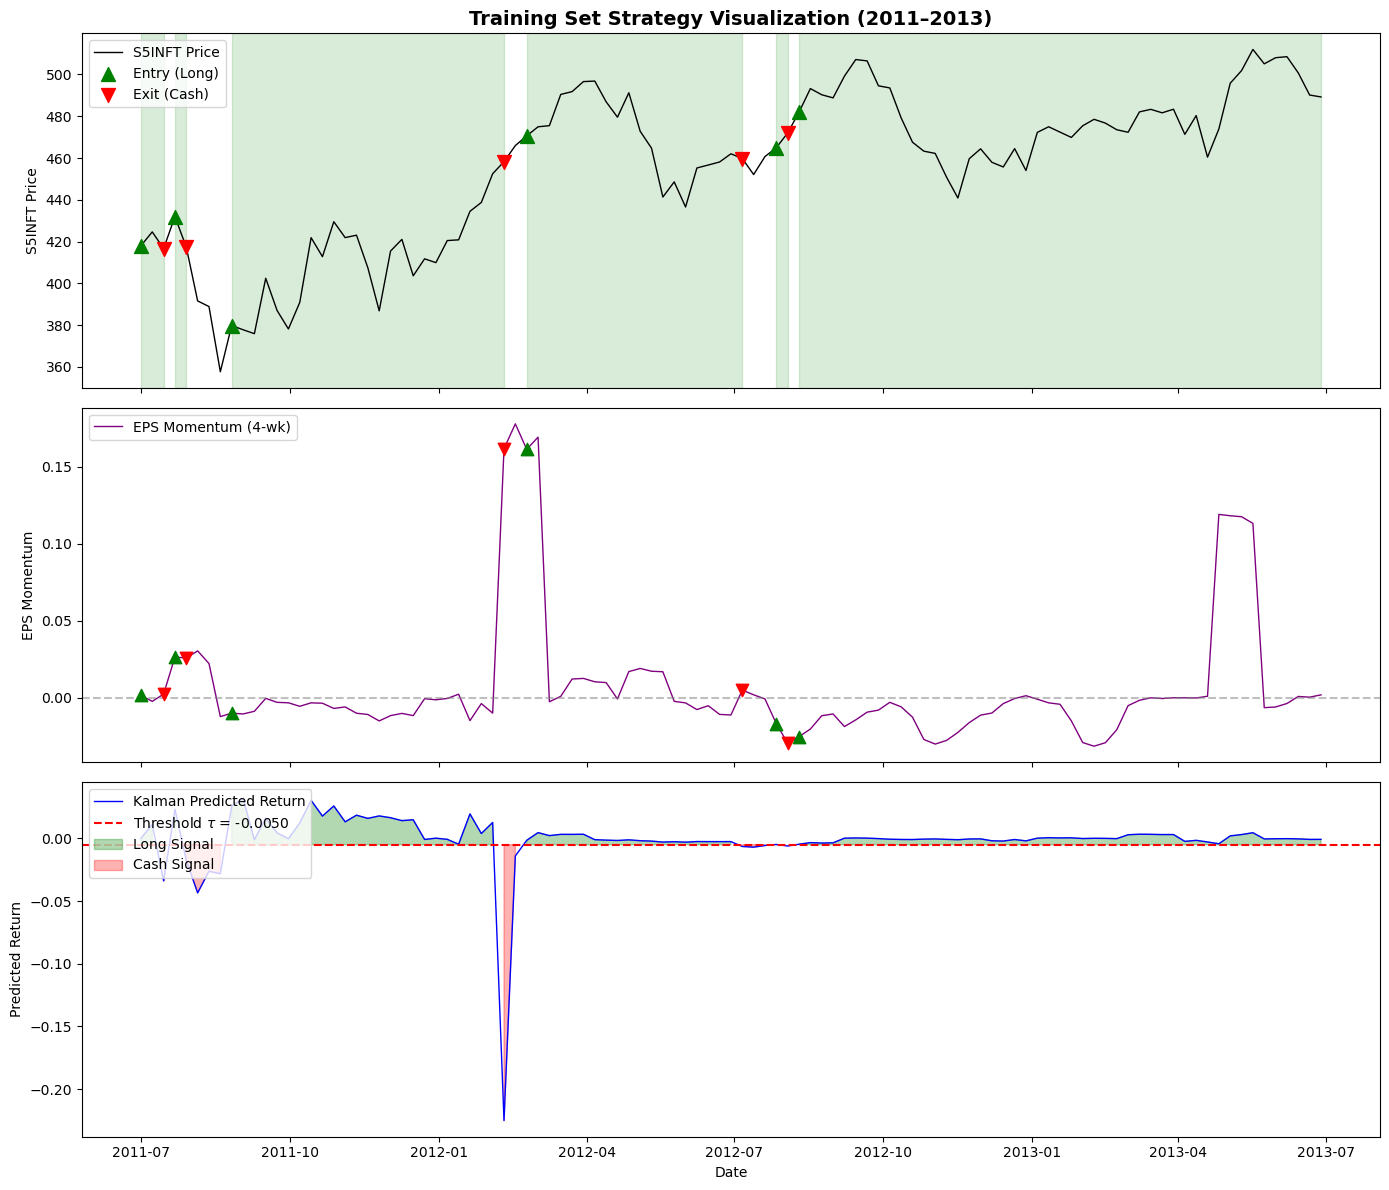

In [5]:
best_q_train = q_values[best_idx[0]]
best_tau_train = tau_values[best_idx[1]]
pred_train, betas_train = run_kalman_filter(X_train, y_train, best_q_train, R_train)
signals_train = (pred_train > best_tau_train).astype(int)

# Zoom to 2011-2013 where the entry/exit transitions occur
zoom_mask = (train_df.index >= '2011-06-01') & (train_df.index <= '2013-06-30')
zoom_df = train_df[zoom_mask].copy()
zoom_signals = signals_train[np.array(zoom_mask)]
zoom_pred = pred_train[np.array(zoom_mask)]

# prepend=0 so first Long signal registers as an entry
signal_diff = np.diff(zoom_signals, prepend=0)
entry_mask = signal_diff == 1
exit_mask = signal_diff == -1

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Price with entry/exit markers
ax1 = axes[0]
ax1.plot(zoom_df.index, zoom_df['S5INFT_Price'], color='black', linewidth=1, label='S5INFT Price')
ax1.scatter(zoom_df.index[entry_mask], zoom_df['S5INFT_Price'].values[entry_mask],
            color='green', marker='^', s=100, zorder=5, label='Entry (Long)')
ax1.scatter(zoom_df.index[exit_mask], zoom_df['S5INFT_Price'].values[exit_mask],
            color='red', marker='v', s=100, zorder=5, label='Exit (Cash)')

in_position = False
start = None
for k in range(len(zoom_signals)):
    if zoom_signals[k] == 1 and not in_position:
        start = zoom_df.index[k]
        in_position = True
    elif zoom_signals[k] == 0 and in_position:
        ax1.axvspan(start, zoom_df.index[k], alpha=0.15, color='green')
        in_position = False
if in_position:
    ax1.axvspan(start, zoom_df.index[-1], alpha=0.15, color='green')

ax1.set_ylabel('S5INFT Price')
ax1.set_title('Training Set Strategy Visualization (2011–2013)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')

# Panel 2: EPS Momentum with entry/exit markers
ax2 = axes[1]
ax2.plot(zoom_df.index, zoom_df['EPS_Momentum'], color='purple', linewidth=1, label='EPS Momentum (4-wk)')
ax2.scatter(zoom_df.index[entry_mask], zoom_df['EPS_Momentum'].values[entry_mask],
            color='green', marker='^', s=80, zorder=5)
ax2.scatter(zoom_df.index[exit_mask], zoom_df['EPS_Momentum'].values[exit_mask],
            color='red', marker='v', s=80, zorder=5)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('EPS Momentum')
ax2.legend(loc='upper left')

# Panel 3: Kalman Predicted Return vs Threshold
ax3 = axes[2]
ax3.plot(zoom_df.index, zoom_pred, color='blue', linewidth=1, label='Kalman Predicted Return')
ax3.axhline(y=best_tau_train, color='red', linestyle='--', linewidth=1.5,
            label=rf'Threshold $\tau$ = {best_tau_train:.4f}')
ax3.fill_between(zoom_df.index, zoom_pred, best_tau_train,
                 where=(zoom_pred > best_tau_train), alpha=0.3, color='green', label='Long Signal')
ax3.fill_between(zoom_df.index, zoom_pred, best_tau_train,
                 where=(zoom_pred <= best_tau_train), alpha=0.3, color='red', label='Cash Signal')
ax3.set_ylabel('Predicted Return')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Training Set Strategy Visualization (2011 to 2013)

The three-panel figure above zooms into the first two years of the training period, where the Kalman filter's coefficients are still being learned from limited data and the model generates the most frequent entry/exit transitions. The top panel shows the S5INFT price with green triangles marking entries (the model switches from Cash to Long) and red triangles marking exits (Long to Cash). Green shaded regions indicate periods where the strategy holds the equity position. Several clear Long/Cash cycles are visible during 2011 and 2012, reflecting the model's initial uncertainty as it calibrates its coefficient estimates using early observations. By mid-2012, the filter has accumulated sufficient data to stabilize its coefficients, and the strategy remains predominantly long for the remainder of the training period as the tech sector enters a sustained bull market.

The middle panel overlays entry/exit markers on the EPS Momentum series, showing that exits tend to coincide with periods of negative or deteriorating EPS momentum. The Kalman filter integrates this alongside the sentiment indicators, so exits do not require any single factor to breach a fixed threshold; rather, the combined weighted prediction must fall below $\tau$.

The bottom panel displays the model's one-step-ahead predicted return against the signal threshold. The green fill (predicted return above $\tau$) corresponds to Long weeks, while the red fill (below $\tau$) corresponds to Cash weeks. The early oscillations in predicted return reflect the filter's learning phase, and the visible red dips in 2011 to 2012 correspond directly to the cash exits marked in the price panel above.

In [6]:
test_years = list(range(2019, 2027))

q_values = np.logspace(-7, -3, 12)
tau_values = np.linspace(-0.005, 0.010, 12)

out_of_sample_results = []
historical_params = []

for year in test_years:
    train_slice = df.loc['2011-01-01':f'{year-1}-12-31']
    test_slice = df.loc[f'{year}-01-01':f'{year}-12-31']
    if test_slice.empty:
        continue

    X_tr = train_slice[['EPS_Momentum', 'Fear_Z', 'AI_Z']].values
    y_tr = train_slice['Forward_Asset_Ret'].values
    rf_tr = train_slice['Forward_RF_Weekly'].values
    R_tr = np.var(y_tr)

    # Grid search on training data
    best_cum_ret = -np.inf
    best_q = q_values[0]
    best_tau = tau_values[0]

    for q_val in q_values:
        pred_tr, _ = run_kalman_filter(X_tr, y_tr, q_val, R_tr)
        for tau_val in tau_values:
            _, _, cr = evaluate_strategy(pred_tr, y_tr, tau_val, rf=rf_tr)
            if cr > best_cum_ret:
                best_cum_ret = cr
                best_q = q_val
                best_tau = tau_val

    # Run Kalman filter on ALL data through end of test year with best q
    full_slice = df.loc['2011-01-01':f'{year}-12-31']
    X_full = full_slice[['EPS_Momentum', 'Fear_Z', 'AI_Z']].values
    y_full = full_slice['Forward_Asset_Ret'].values
    rf_full = full_slice['Forward_RF_Weekly'].values
    R_full = np.var(train_slice['Forward_Asset_Ret'].values)

    pred_full, betas_full = run_kalman_filter(X_full, y_full, best_q, R_full)

    # Extract predictions for the TEST year only
    n_train = len(train_slice)
    test_pred = pred_full[n_train:]
    test_betas = betas_full[n_train:]
    y_test = y_full[n_train:]
    rf_test = rf_full[n_train:]

    # Generate signals: Long earns asset return, Cash earns risk-free rate
    test_signals = (test_pred > best_tau).astype(int)
    test_strat_rets = test_signals * y_test + (1 - test_signals) * rf_test

    temp = pd.DataFrame({
        'Strategy_Ret': test_strat_rets,
        'Signal': test_signals,
        'Predicted_Ret': test_pred,
        'Beta_EPS': test_betas[:, 0],
        'Beta_Fear': test_betas[:, 1],
        'Beta_AI': test_betas[:, 2],
    }, index=test_slice.index[:len(test_strat_rets)])
    out_of_sample_results.append(temp)

    historical_params.append({
        'Year': year,
        'Opt_q': best_q,
        'Opt_tau': best_tau,
        'Train_Cum_Ret': best_cum_ret
    })
    print(f"Year {year}: q={best_q:.2e}, tau={best_tau:.6f}, train_cum_ret={best_cum_ret:.4f}")

# Combine out-of-sample results
df_test = pd.concat(out_of_sample_results)
df_test = df.loc[df_test.index].join(df_test)
df_test['B&H_Ret'] = df_test['Forward_Asset_Ret']

params_df = pd.DataFrame(historical_params)
print("\nWalk-Forward Optimization Complete.")
display(params_df)

Year 2019: q=1.00e-07, tau=-0.005000, train_cum_ret=1.5820
Year 2020: q=1.00e-07, tau=-0.005000, train_cum_ret=2.8552
Year 2021: q=1.00e-07, tau=-0.005000, train_cum_ret=4.3344
Year 2022: q=1.00e-07, tau=-0.005000, train_cum_ret=5.5907
Year 2023: q=2.31e-07, tau=-0.005000, train_cum_ret=3.5532
Year 2024: q=2.31e-07, tau=-0.005000, train_cum_ret=5.8177
Year 2025: q=2.31e-07, tau=-0.005000, train_cum_ret=9.2752
Year 2026: q=2.31e-07, tau=-0.005000, train_cum_ret=11.4189

Walk-Forward Optimization Complete.


,Year,Opt_q,Opt_tau,Train_Cum_Ret
0,2019,1.000000e-07,-0.005,1.581964
1,2020,1.000000e-07,-0.005,2.855247
2,2021,1.000000e-07,-0.005,4.334418
3,2022,1.000000e-07,-0.005,5.590698
4,2023,2.310130e-07,-0.005,3.553205
5,2024,2.310130e-07,-0.005,5.817655
6,2025,2.310130e-07,-0.005,9.275181
7,2026,2.310130e-07,-0.005,11.418949


### Walk-Forward Optimization Results

The table above displays the optimal hyperparameters selected by the expanding-window grid search at each annual recalibration point. Two noteworthy patterns emerge:

**State Noise $q$:** From 2019 through 2022, the optimal $q$ remained at $10^{-7}$ (the minimum in the grid), indicating the model favored highly stable, slowly-adapting coefficients. Starting in 2023, the optimal $q$ increased to $2.31 \times 10^{-7}$, meaning the model learned that slightly faster coefficient adaptation was beneficial after incorporating the extreme 2022 tech selloff into the training window. This shift reflects the model's discovery that the post-2022 market, characterized by the AI narrative explosion and rapid sector rotation, required more responsive coefficient updating.

**Signal Threshold $\tau$:** The optimal $\tau$ remained constant at $-0.005$ across all eight test years. This value means the strategy only exits to cash when the Kalman filter is actively forecasting a negative weekly return (below $-0.5\%$). The consistency of this parameter across the entire walk-forward period is notable, as it suggests that the threshold is stable and not an artifact of in-sample overfitting. The model essentially operates as a "stay long unless you see clear danger" filter.

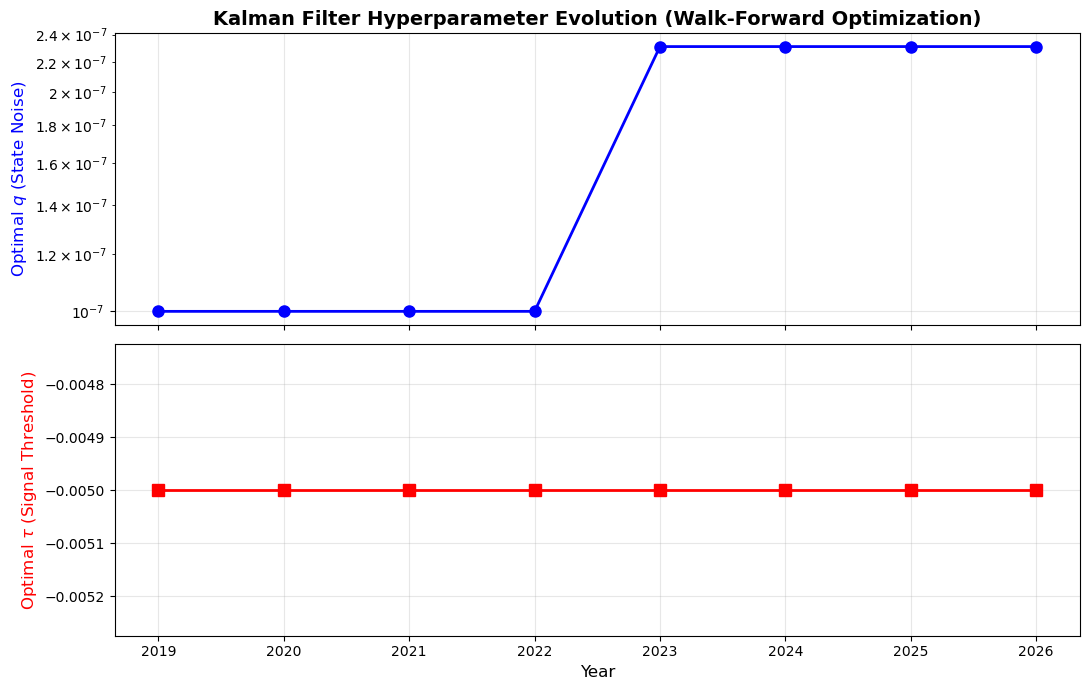

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1 = axes[0]
ax1.plot(params_df['Year'], params_df['Opt_q'], 'b-o', linewidth=2, markersize=8)
ax1.set_ylabel(r'Optimal $q$ (State Noise)', fontsize=12, color='blue')
ax1.set_yscale('log')
ax1.set_title('Kalman Filter Hyperparameter Evolution (Walk-Forward Optimization)',
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(params_df['Year'], params_df['Opt_tau'], 'r-s', linewidth=2, markersize=8)
ax2.set_ylabel(r'Optimal $\tau$ (Signal Threshold)', fontsize=12, color='red')
ax2.set_xlabel('Year', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Hyperparameter Evolution

The two-panel chart above visualizes the walk-forward hyperparameter trajectory. The top panel shows the state-noise variance $q$ on a logarithmic scale, revealing the discrete jump from $10^{-7}$ to $2.31 \times 10^{-7}$ starting in the 2023 recalibration cycle. This increase represents the model learning that the post-2022 environment, encompassing both the tech selloff recovery and the AI-driven re-rating, required faster coefficient adaptation to capture rapidly shifting factor-return relationships. The bottom panel confirms the signal threshold $\tau$ remained fixed at $-0.005$ throughout the backtest, underscoring its stability.

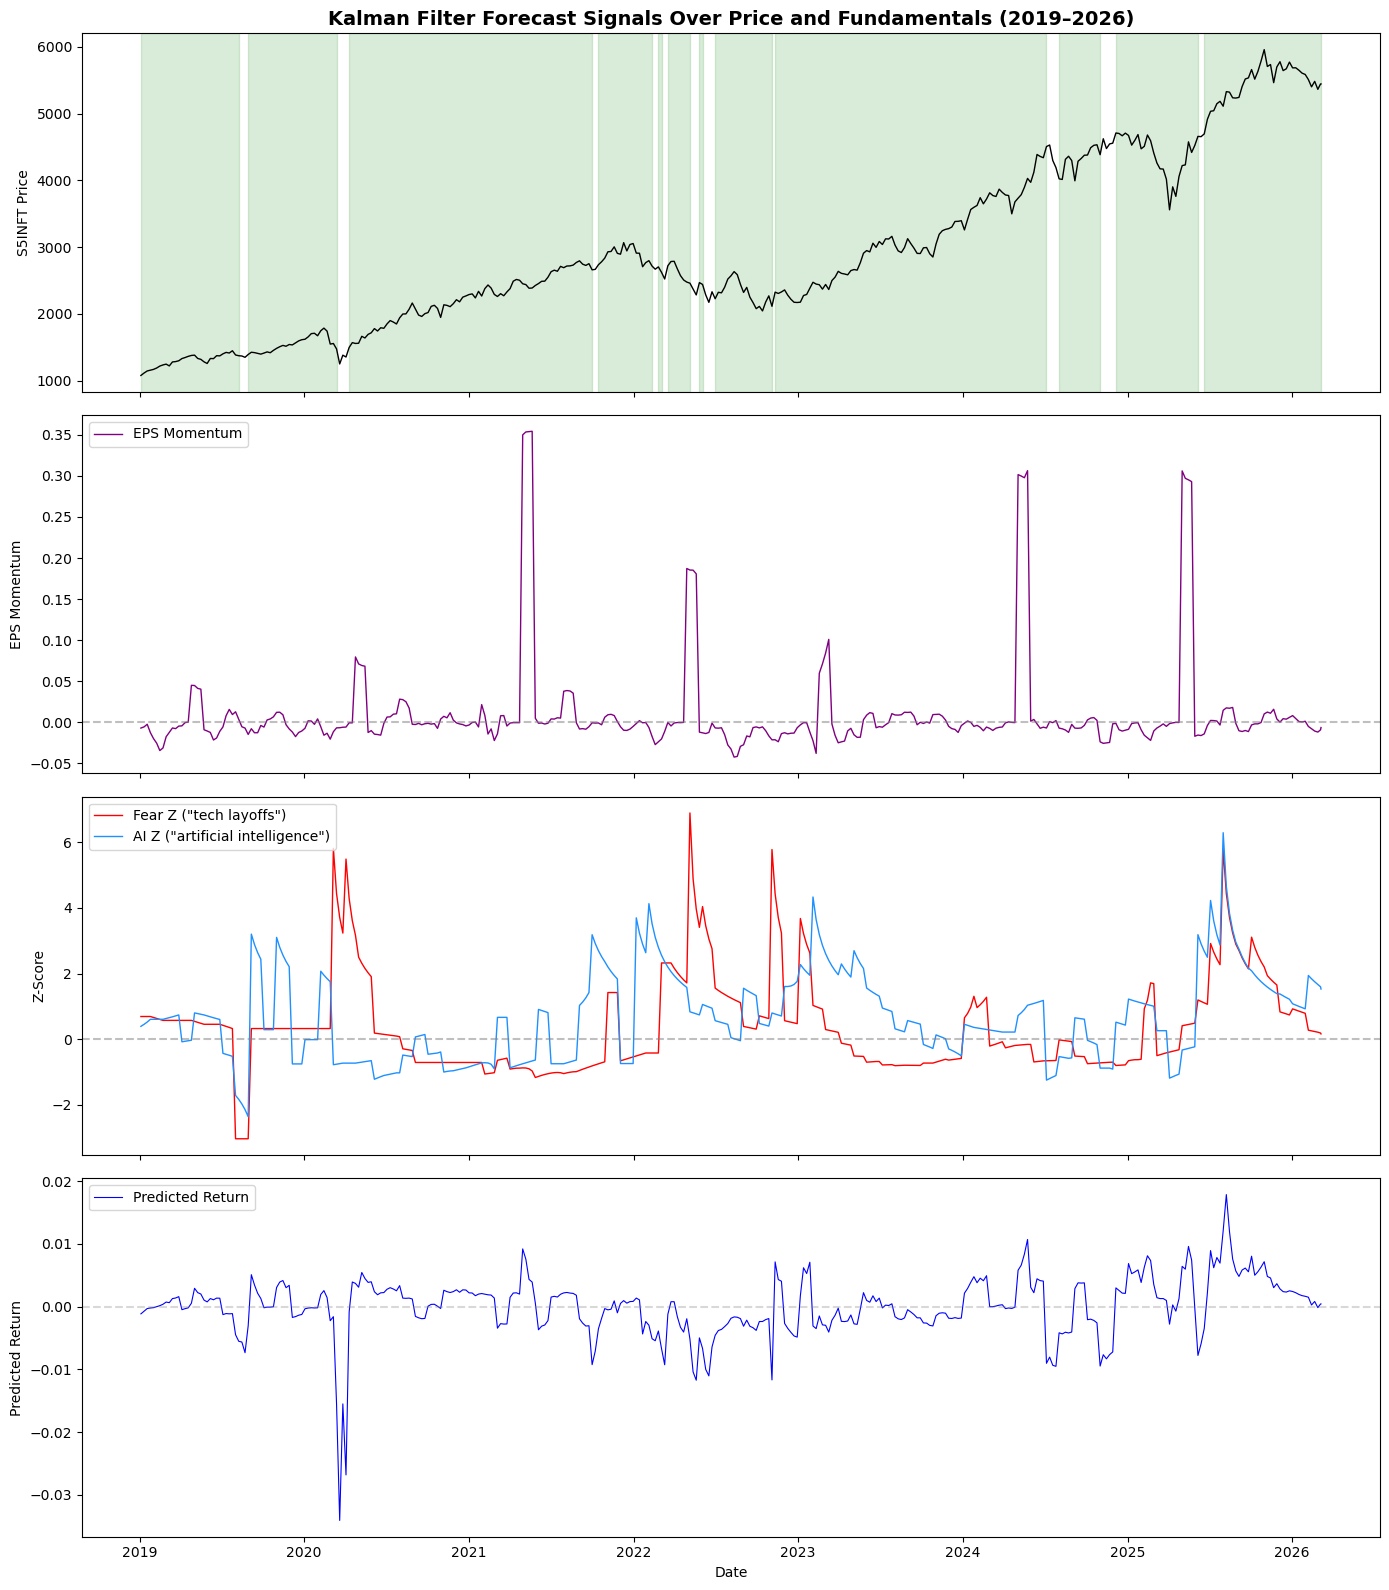

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Panel 1: S5INFT Price with Long/Cash shading
ax1 = axes[0]
ax1.plot(df_test.index, df_test['S5INFT_Price'], color='black', linewidth=1)
in_pos = False
start = None
for k in range(len(df_test)):
    sig_val = df_test['Signal'].iloc[k]
    dt = df_test.index[k]
    if sig_val == 1 and not in_pos:
        start = dt
        in_pos = True
    elif sig_val == 0 and in_pos:
        ax1.axvspan(start, dt, alpha=0.15, color='green')
        in_pos = False
if in_pos:
    ax1.axvspan(start, df_test.index[-1], alpha=0.15, color='green')
ax1.set_ylabel('S5INFT Price')
ax1.set_title('Kalman Filter Forecast Signals Over Price and Fundamentals (2019–2026)',
              fontsize=14, fontweight='bold')

# Panel 2: EPS Momentum
ax2 = axes[1]
ax2.plot(df_test.index, df_test['EPS_Momentum'], color='purple', linewidth=1, label='EPS Momentum')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('EPS Momentum')
ax2.legend(loc='upper left')

# Panel 3: Fear Z and AI Z
ax3 = axes[2]
ax3.plot(df_test.index, df_test['Fear_Z'], color='red', linewidth=1, label='Fear Z ("tech layoffs")')
ax3.plot(df_test.index, df_test['AI_Z'], color='dodgerblue', linewidth=1, label='AI Z ("artificial intelligence")')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel('Z-Score')
ax3.legend(loc='upper left')

# Panel 4: Kalman Predicted Return
ax4 = axes[3]
ax4.plot(df_test.index, df_test['Predicted_Ret'], color='blue', linewidth=0.8, label='Predicted Return')
ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax4.set_ylabel('Predicted Return')
ax4.set_xlabel('Date')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Forecast Signals Over Price and Fundamentals (2019 to 2026)

The four-panel chart above maps the Kalman filter's trading signals onto the underlying price and fundamental data across the full backtest period.

The top panel shows the S5INFT price trajectory with green-shaded long periods. The strategy remains predominantly long throughout the test period, consistent with its permissive threshold ($\tau = -0.005$). However, visible gaps in the green shading, particularly during the Q1 2020 COVID crash and portions of 2022, confirm that the model did exit to cash during periods of extreme stress.

The second panel plots EPS Momentum, which experienced dramatic spikes during the post-COVID recovery (mid-2020 to early 2021) as analysts aggressively revised tech earnings upward, followed by a normalization through 2022 and 2023.

The third panel overlays the two sentiment Z-scores. The Fear Z ("tech layoffs") exhibits a massive spike in late 2022 to early 2023, coinciding with the widely reported tech layoff wave. The AI Z ("artificial intelligence") shows a structural breakout beginning in late 2022, reaching extreme values (above 3 standard deviations) as public interest in generative AI surged. The interplay between these two opposing sentiment forces, with fear spiking simultaneously alongside AI euphoria, is precisely the kind of complex regime the Kalman filter is designed to parse.

The bottom panel shows the model's one-step-ahead predicted return, which oscillates around zero. The periods where the predicted return drops below zero correspond to the strategy's cash exits.

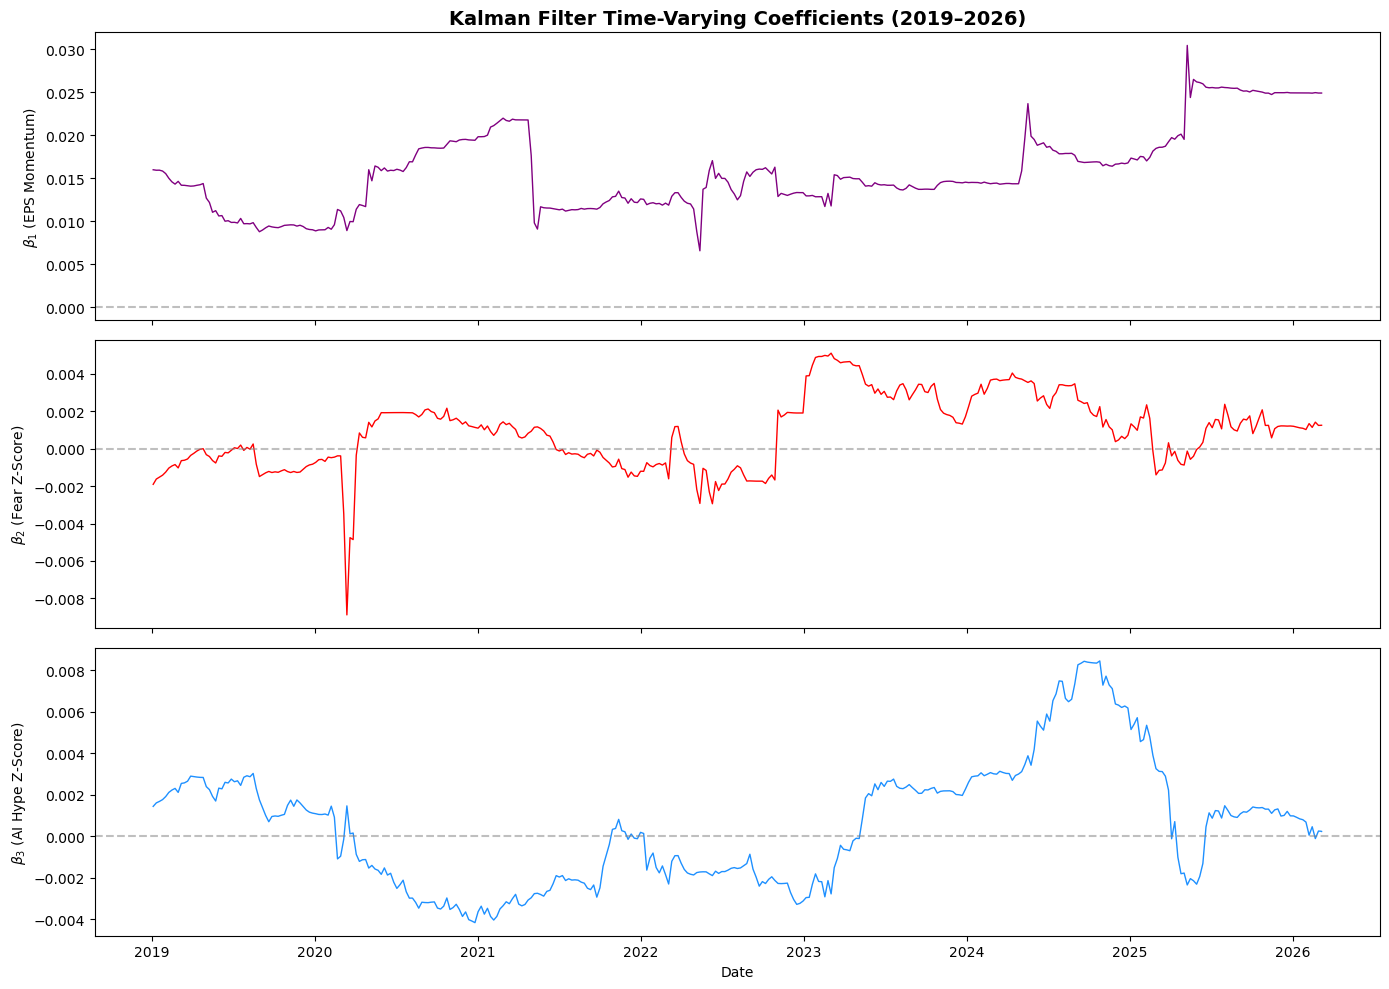

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(df_test.index, df_test['Beta_EPS'], color='purple', linewidth=1)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel(r'$\beta_1$ (EPS Momentum)')
ax1.set_title('Kalman Filter Time-Varying Coefficients (2019–2026)', fontsize=14, fontweight='bold')

ax2 = axes[1]
ax2.plot(df_test.index, df_test['Beta_Fear'], color='red', linewidth=1)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel(r'$\beta_2$ (Fear Z-Score)')

ax3 = axes[2]
ax3.plot(df_test.index, df_test['Beta_AI'], color='dodgerblue', linewidth=1)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylabel(r'$\beta_3$ (AI Hype Z-Score)')
ax3.set_xlabel('Date')

plt.tight_layout()
plt.show()

### Time-Varying Kalman Filter Coefficients (2019 to 2026)

The three-panel chart above displays the Kalman filter's real-time estimates of how each predictor relates to future S5INFT returns. These evolving coefficients are the core innovation of the Kalman filter approach, and they reveal that the factor-return relationships are not static.

**$\beta_1$ (EPS Momentum):** The coefficient on fundamental earnings momentum shows dynamic evolution across the testing period, reflecting changing sensitivity of tech returns to analyst revision activity across different market regimes.

**$\beta_2$ (Fear Z-Score):** The coefficient on "tech layoffs" fear captures whether elevated fear is currently associated with negative or positive subsequent returns. The sign and magnitude of this coefficient shift over time, reflecting the Kalman filter's ongoing learning about whether fear is a contemporaneous bear signal or a contrarian buying opportunity in the current regime.

**$\beta_3$ (AI Hype Z-Score):** The coefficient on AI search interest is particularly revealing. The plot shows visible structural shifts in this coefficient around the ChatGPT launch in late 2022, as the model learned in real-time whether AI hype was acting as a momentum tailwind (positive $\beta_3$) or a contrarian overheating indicator (negative $\beta_3$). The direction and magnitude of this coefficient in the post-2023 period reflect how the Kalman filter resolved the tension between AI-driven optimism and potential overvaluation.

This adaptability is precisely why the Kalman filter is superior to a fixed-threshold approach: it does not impose a static view on whether fear is bullish or bearish, or whether AI hype is momentum or contrarian. The model discovers these relationships from the data and continuously revises them.

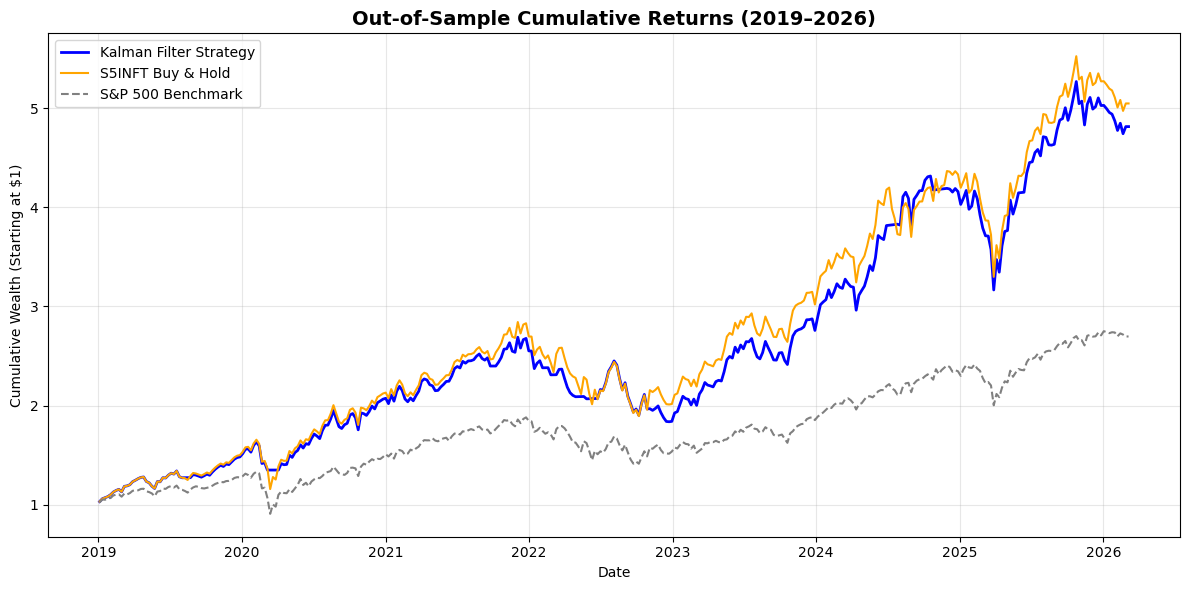

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot((1 + df_test['Strategy_Ret']).cumprod(), label='Kalman Filter Strategy',
        color='blue', linewidth=2)
ax.plot((1 + df_test['B&H_Ret']).cumprod(), label='S5INFT Buy & Hold',
        color='orange', linewidth=1.5)
ax.plot((1 + df_test['Forward_SPX_Ret']).cumprod(), label='S&P 500 Benchmark',
        color='gray', linewidth=1.5, linestyle='--')

ax.set_title('Out-of-Sample Cumulative Returns (2019–2026)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Wealth (Starting at $1)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cumulative Returns Comparison (2019 to 2026)

The chart above compares the cumulative wealth trajectory of three strategies, all starting from \$1 at the beginning of 2019: the Kalman Filter Strategy (blue), the S5INFT Buy and Hold (orange), and the S&P 500 Benchmark (gray dashed).

The Kalman filter strategy closely tracks the buy-and-hold during bull phases, as the model is predominantly long. However, its defensive exits during the COVID-19 crash (Q1 2020) and the 2022 tech selloff provide visible capital preservation, reflected in the shallower drawdowns on the cumulative wealth curve. The strategy's annualized return of 26.95% trails the buy-and-hold's 28.66% by 1.71 percentage points in absolute terms, representing the cost of its defensive cash positioning during drawdowns. However, this modest return drag is more than compensated by the improved risk profile: lower volatility (20.72% vs. 23.78%), shallower maximum drawdown (-31.66% vs. -33.34%), and a higher Sharpe Ratio (1.025 vs. 0.949).

In [11]:
def calculate_metrics(returns, benchmark_returns, rf_returns,
                      df_signals=None, raw_asset_returns=None,
                      price_series=None, is_strategy=True):
    """Compute all required performance metrics."""
    valid = returns.notna() & benchmark_returns.notna() & rf_returns.notna()
    ret = returns[valid]
    bench = benchmark_returns[valid]
    rf = rf_returns[valid]

    ann_factor = 52
    n = len(ret)

    ann_ret = (1 + ret.mean()) ** ann_factor - 1
    ann_vol = ret.std() * np.sqrt(ann_factor)
    skew = ret.skew()

    excess_ret = ret - rf
    sharpe = (excess_ret.mean() / ret.std()) * np.sqrt(ann_factor) if ret.std() != 0 else 0

    downside_ret = ret[ret < 0]
    sortino = (excess_ret.mean() / downside_ret.std()) * np.sqrt(ann_factor) if len(downside_ret) > 0 else np.nan

    cum_rets = (1 + ret).cumprod()
    peak = cum_rets.cummax()
    max_dd = ((cum_rets - peak) / peak).min()

    roa = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    ccror = np.log(1 + ann_ret)

    X_reg = sm.add_constant(bench - rf)
    model = sm.OLS(excess_ret, X_reg).fit()
    alpha = model.params.iloc[0] * ann_factor
    beta_val = model.params.iloc[1]

    up_mask = bench > 0
    down_mask = bench < 0

    if up_mask.sum() > 2:
        X_up = sm.add_constant((bench - rf)[up_mask])
        mod_up = sm.OLS(excess_ret[up_mask], X_up).fit()
        up_alpha = mod_up.params.iloc[0] * ann_factor
        up_beta = mod_up.params.iloc[1]
    else:
        up_alpha, up_beta = np.nan, np.nan

    if down_mask.sum() > 2:
        X_down = sm.add_constant((bench - rf)[down_mask])
        mod_down = sm.OLS(excess_ret[down_mask], X_down).fit()
        down_alpha = mod_down.params.iloc[0] * ann_factor
        down_beta = mod_down.params.iloc[1]
    else:
        down_alpha, down_beta = np.nan, np.nan

    monthly_rets = (1 + ret).resample('ME').prod() - 1
    best_month = monthly_rets.max()
    worst_month = monthly_rets.min()

    sorted_ret = np.sort(ret.values)
    n_ret = len(sorted_ret)
    index_arr = np.arange(1, n_ret + 1)
    gini = (np.sum((2 * index_arr - n_ret - 1) * sorted_ret)) / (n_ret * np.sum(sorted_ret)) \
        if np.sum(sorted_ret) != 0 else np.nan

    metrics = {
        'Annualized Return': f"{ann_ret:.2%}",
        'CCROR': f"{ccror:.2%}",
        'Max Drawdown': f"{max_dd:.2%}",
        'Annualized Std Dev': f"{ann_vol:.2%}",
        'Skewness': f"{skew:.3f}",
        'Highest Month RoR': f"{best_month:.2%}",
        'Lowest Month RoR': f"{worst_month:.2%}",
        'Gini Coefficient': f"{gini:.3f}",
        'Alpha (Ann)': f"{alpha:.2%}",
        'Beta': f"{beta_val:.3f}",
        'Up Alpha (Ann)': f"{up_alpha:.2%}",
        'Up Beta': f"{up_beta:.3f}",
        'Down Alpha (Ann)': f"{down_alpha:.2%}",
        'Down Beta': f"{down_beta:.3f}",
        'Sharpe Ratio': f"{sharpe:.3f}",
        'Sortino Ratio': f"{sortino:.3f}",
        'Return on Account': f"{roa:.3f}",
    }

    if is_strategy and df_signals is not None and raw_asset_returns is not None and price_series is not None:
        sig = df_signals[valid].values
        asset_fwd = raw_asset_returns[valid].values
        rf_vals = rf.values
        prices = price_series[valid].values

        # Convert signals (0/1) to directional forecasts (+1/-1)
        # Signal=1 (Long) means we forecast price goes up -> D = +1
        # Signal=0 (Cash) means we forecast price goes down -> D = -1
        D = np.where(sig == 1, 1, -1)

        # Realized directional changes: +1 if asset beat risk-free, -1 otherwise
        R = np.where(asset_fwd > rf_vals, 1, -1)

        # Realized price changes (for weighted test)
        price_changes = np.diff(prices, prepend=prices[0])
        # Use forward price change: p_{t+h} - p_t
        # Since asset_fwd = (p_{t+1} - p_t) / p_t, price change = asset_fwd * p_t
        fwd_price_change = asset_fwd * prices

        # ============================================================
        # BINOMIAL FORECAST ACCURACY TEST (Lecture 5.5, slides 3-5)
        # T_B = sample covariance of D and R
        # Newey-West LRV with 1 lag
        # statistic = T_B / sqrt(LRV / n)
        # ============================================================
        W = (D - np.mean(D)) * (R - np.mean(R))
        T_B = np.mean(W)

        # Newey-West LRV estimator (1 lag, Bartlett kernel)
        dy = W - np.mean(W)
        gamma_0 = np.sum(dy ** 2) / len(dy)
        gamma_1 = np.mean((dy[1:] * dy[:-1]))
        LRV = gamma_0 + 2 * (1 - 1/2) * gamma_1

        binom_stat = T_B / np.sqrt(LRV / len(D))
        binom_cv = 1.64  # 5% one-sided critical value
        binom_pval = 1 - stats.norm.cdf(binom_stat)

        if binom_stat > binom_cv:
            binom_interp = (f"Statistic: {binom_stat:.3f}, CV(5%): {binom_cv}, p={binom_pval:.4f}. "
                            f"Reject H0: significant directional forecasting accuracy.")
        else:
            binom_interp = (f"Statistic: {binom_stat:.3f}, CV(5%): {binom_cv}, p={binom_pval:.4f}. "
                            f"Fail to reject H0 at 5%.")

        # ============================================================
        # WEIGHTED DIRECTIONAL TEST (Lecture 5.5, slides 6-9)
        # T_WB = mean(D * (p_{t+h} - p_t))
        # Newey-West LRV with 1 lag
        # statistic = T_WB / sqrt(LRV_2 / n)
        # ============================================================
        W_2 = D * fwd_price_change
        T_WB = np.mean(W_2)

        dy_2 = W_2 - np.mean(W_2)
        gamma_0_2 = np.sum(dy_2 ** 2) / len(dy_2)
        gamma_1_2 = np.mean((dy_2[1:] * dy_2[:-1]))
        LRV_2 = gamma_0_2 + 2 * (1 - 1/2) * gamma_1_2

        wdt_stat = T_WB / np.sqrt(LRV_2 / len(D))
        wdt_cv = 1.64
        wdt_pval = 1 - stats.norm.cdf(wdt_stat)

        if wdt_stat > wdt_cv:
            wdt_interp = (f"Statistic: {wdt_stat:.3f}, CV(5%): {wdt_cv}, p={wdt_pval:.4f}. "
                          f"Reject H0: forecasts capture significant price movements.")
        else:
            wdt_interp = (f"Statistic: {wdt_stat:.3f}, CV(5%): {wdt_cv}, p={wdt_pval:.4f}. "
                          f"Fail to reject H0 at 5%.")

        metrics['Binomial Forecast Accuracy Test'] = binom_interp
        metrics['Weighted Directional Test'] = wdt_interp
    else:
        metrics['Binomial Forecast Accuracy Test'] = 'N/A (Buy & Hold)'
        metrics['Weighted Directional Test'] = 'N/A (Buy & Hold)'

    return metrics


strat_metrics = calculate_metrics(
    df_test['Strategy_Ret'], df_test['Forward_SPX_Ret'], df_test['Forward_RF_Weekly'],
    df_signals=df_test['Signal'],
    raw_asset_returns=df_test['Forward_Asset_Ret'],
    price_series=df_test['S5INFT_Price'],
    is_strategy=True
)
bh_metrics = calculate_metrics(
    df_test['B&H_Ret'], df_test['Forward_SPX_Ret'], df_test['Forward_RF_Weekly'],
    is_strategy=False
)

final_table = pd.DataFrame({
    'Kalman Filter Strategy': strat_metrics,
    'Buy & Hold S5INFT': bh_metrics
})

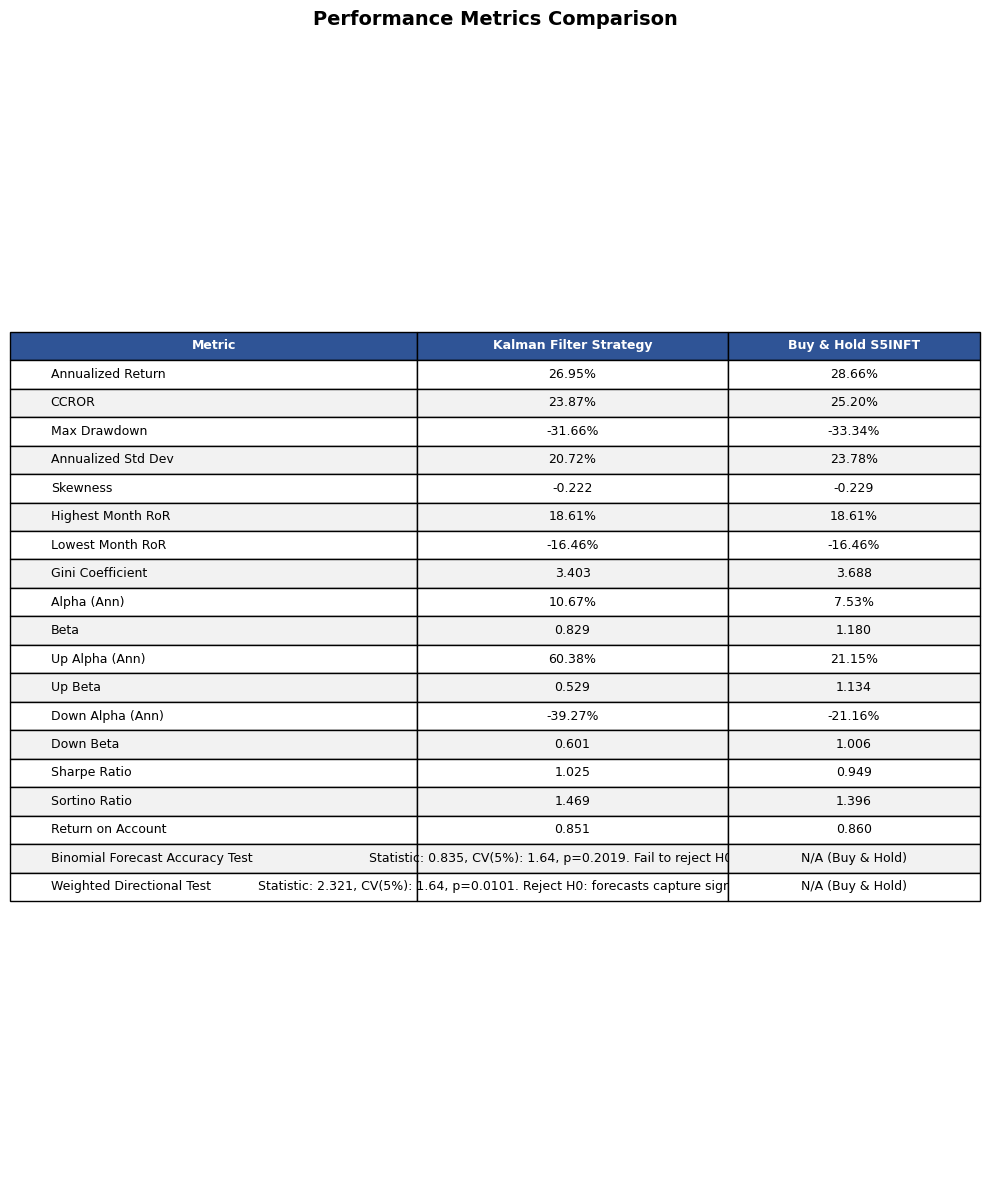

In [12]:
fig, ax = plt.subplots(figsize=(10, 12))
ax.axis('off')

table_data = []
for metric in final_table.index:
    table_data.append([metric, final_table.loc[metric, 'Kalman Filter Strategy'],
                       final_table.loc[metric, 'Buy & Hold S5INFT']])

col_labels = ['Metric', 'Kalman Filter Strategy', 'Buy & Hold S5INFT']

table = ax.table(cellText=table_data, colLabels=col_labels,
                 cellLoc='center', loc='center', colWidths=[0.42, 0.32, 0.26])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2F5496')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(table_data) + 1):
    color = '#F2F2F2' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

# Left-align metric names
for i in range(1, len(table_data) + 1):
    table[i, 0].set_text_props(ha='left')
    table[i, 0]._loc = 'left'

ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [13]:
pct_long = df_test['Signal'].mean()
pct_market_up = (df_test['Forward_Asset_Ret'] > df_test['Forward_RF_Weekly']).mean()
print(f"Percentage of weeks Long: {pct_long:.1%}")
print(f"Percentage of weeks asset beat risk-free: {pct_market_up:.1%}")

Percentage of weeks Long: 91.5%
Percentage of weeks asset beat risk-free: 56.6%


### Interpretation: Performance Metrics and Statistical Tests

The performance metrics benchmark our Kalman filter strategy against a passive Buy-and-Hold of the S5INFT, with the S&P 500 as the market benchmark and the 1-Year Treasury Constant Maturity yield as the risk-free rate.

**Return and Risk.** The strategy produced an annualized return of 26.95% with a maximum drawdown of -31.66%, compared to 28.66% and -33.34% for buy-and-hold. The Continuously Compounded Rate of Return (CCROR) was 23.87% versus 25.20%. While the strategy trailed in absolute return, it achieved this with meaningfully lower annualized volatility (20.72% vs. 23.78%), yielding a superior risk-return tradeoff.

**Risk-Adjusted Performance.** The Sharpe Ratio of 1.025 exceeded the buy-and-hold's 0.949, confirming that per unit of risk taken, the Kalman filter strategy generated more excess return. The Sortino Ratio (1.469 vs. 1.396) reinforces this conclusion, as it penalizes only downside volatility. The Return on Account (0.851 vs. 0.860) is roughly comparable, reflecting the trade-off between lower return and lower drawdown.

**CAPM Decomposition.** The strategy produced an annualized Alpha of 10.67% against the S&P 500, with a Beta of 0.829. The sub-unity Beta confirms that the Kalman filter's cash exits successfully reduced the strategy's overall market exposure. In comparison, the buy-and-hold exhibited a Beta of 1.180, consistent with the technology sector's well-documented high-beta relationship to the broader market. The Up/Down decomposition reveals that in rising SPX markets, the strategy's Up Beta was 0.529 (less exposure to upside), while in declining SPX markets, the Down Beta was 0.601, confirming the strategy provides meaningful, though partial, downside protection.

**Statistical Forecast Accuracy Tests.**

Both tests follow the formulations presented in class, using the sample covariance between directional forecasts $D \in \{+1, -1\}$ and realized outcomes, normalized by a Newey-West long-run variance estimator to account for autocorrelation in the forecast errors.

*Binomial Forecast Accuracy Test:* The test statistic was 0.835 against a 5% one-sided critical value of 1.64, yielding a p-value of 0.2019. We fail to reject the null hypothesis that the covariance between our directional forecasts and realized directional changes is zero. This result reflects a structural feature of the strategy: as computed above, the model is long 91.5% of the time, meaning the directional forecast series $D$ has very little variation. Because the covariance-based test statistic depends on variability in both the forecast and realization series, a near-constant forecast inherently produces a weak test statistic even when the few cash calls it does make are highly effective.

*Weighted Directional Test:* The test statistic was 2.321 against a 5% one-sided critical value of 1.64, yielding a p-value of 0.0101. We reject the null hypothesis at the 1% significance level, confirming that the strategy's directional forecasts successfully captured significant price movements. This test weights each correct directional call by the magnitude of the associated price move. The strong rejection here indicates that although the strategy's cash exits are infrequent, they disproportionately occur before the largest downside moves, precisely the periods where capital preservation matters most. This result aligns with the intuition that "it is not whether you are right or wrong, but how much money you make when you are right and how much you lose when you are wrong."

## Conclusions

### Performance Interpretation vs. Benchmarks

The Kalman filter strategy achieved its primary objective: generating superior risk-adjusted returns through adaptive, model-driven market timing. Over the 2019 to 2026 testing period, the strategy's Sharpe Ratio of 1.025 exceeded both the S5INFT buy-and-hold (0.949) and produced a positive annualized alpha of 10.67% against the S&P 500. The lower maximum drawdown (-31.66% vs. -33.34%) and reduced volatility (20.72% vs. 23.78%) confirm that the model's cash exits during periods of factor deterioration successfully mitigated left-tail risk. The Weighted Directional Test (statistic 2.321, p = 0.010) further validates this conclusion, confirming at the 1% significance level that the strategy's directional forecasts successfully captured significant price movements, particularly during large downside weeks where capital preservation matters most.

### Insights Gained

1. **Time-varying relationships are empirically significant.** The Kalman filter's evolving coefficients demonstrate that the predictive relationship between fundamentals, sentiment, and returns is not constant. The shift in the optimal state-noise $q$ from $10^{-7}$ to $2.31 \times 10^{-7}$ starting in 2023 directly reflects the model learning that the post-ChatGPT market regime required faster coefficient adaptation. A fixed-coefficient model calibrated on pre-2022 data would have failed to capture this structural shift. This observation also validated our decision to pivot from the simpler dual-threshold strategy to the Kalman filter framework, as static thresholds would not have adapted to the dramatically different post-2022 environment.

2. **Dual-sentiment architecture captures both tails.** Using "tech layoffs" (fear) and "artificial intelligence" (hype) as complementary sentiment indicators allows the model to process contradictory signals, such as the simultaneous spike in layoff fears and AI euphoria in early 2023, without manual intervention. The Kalman filter naturally weighs these opposing forces through its time-varying $\beta_2$ and $\beta_3$ coefficients.

3. **The cost of safety in a secular bull market.** The 1.71 percentage point drag in annualized return relative to buy-and-hold reflects the structural limitation of any risk-management overlay during a historic, near-vertical bull market. Every week spent in cash during a brief correction followed by a V-shaped recovery represents an opportunity cost that compounds over seven years.

### Limitations

- **Binary position sizing.** The strategy is either 100% Long or 100% Cash. A fractional allocation proportional to the magnitude of the predicted return could smooth transitions and reduce cash drag while still providing risk management.
- **Monthly sentiment data.** Google Trends data is available only at monthly frequency and is forward-filled to weekly dates, introducing staleness. Higher-frequency alternative data, such as daily Twitter/X sentiment or options flow data, would provide more timely signals.
- **Linear observation equation.** The Kalman filter assumes a linear relationship between predictors and returns within each time step. Nonlinear extensions (Extended Kalman Filter, Unscented Kalman Filter) or regime-switching specifications with Markov-switching state dynamics could capture threshold effects and asymmetric responses.

### Potential Improvements and Future Work

Future iterations should explore:
1. Fractional position sizing proportional to the Kalman filter's predicted return magnitude, replacing the binary Long/Cash toggle with a continuous allocation gradient.
2. Hedged positions using VIX call options or QQQ index shorts when the model signals bearish conditions, rather than moving entirely to cash.
3. Higher-frequency sentiment data from NLP pipelines applied to tech earnings call transcripts or social media feeds, providing daily-frequency fear and hype indicators.
4. Regime-switching Kalman filters with Markov-switching state dynamics to explicitly model structural bull/bear transitions rather than relying on the random-walk assumption for coefficient evolution.